## 11주차 복습과제: 군집화

다음은 11주차 군집화 세션의 복습과제입니다. 문제 조건에 맞춰 코드를 작성하고, 설명을 추가해 주세요.

---

#Section A: 군집화, K-means

문제 1: 좋은 군집화란?

좋은 군집화의 조건을 설명하시오.

**요구 사항**

군집 내부 응집도(Within-cluster similarity)의 의미를 설명하시오.

군집 간 분리도(Between-cluster dissimilarity)의 의미를 설명하시오.



좋은 군집화란 동일한 군집 내의 데이터들은 서로 최대한 유사하게 모여 있고, 서로 다른 군집 간의 데이터들은 최대한 멀리 떨어져 있도록 분류하는 것을 말한다.

군집 내부 응집도(Within-cluster similarity): 하나의 군집 안에 속한 데이터 포인트들이 얼마나 조밀하게 모여 있는지를 의미한다. 응집도가 높을수록(거리가 가까울수록) 좋은 군집화이다.

군집 간 분리도(Between-cluster dissimilarity): 서로 다른 군집들이 얼마나 멀리 떨어져 있는지를 의미한다. 분리도가 높을수록(거리가 멀수록) 좋은 군집화이다.

문제 2: K-Means에서 군집 개수 K는 매우 중요한 파라미터이다.
동일한 데이터에 대해 서로 다른 K값을 적용했을 때 군집화 결과가 어떻게 달라지는지 비교하시오.

데이터 생성 조건
샘플 수 : 400개
군집 수 : 4개
특징 수 : 2개
random_state : 0
수행 조건

다음 K값에 대해 각각 군집화를 수행하시오.

Case 1 : K = 2
Case 2 : K = 4
Case 3 : K = 6
(배운 파라미터를 기반으로 작성하면 됨)

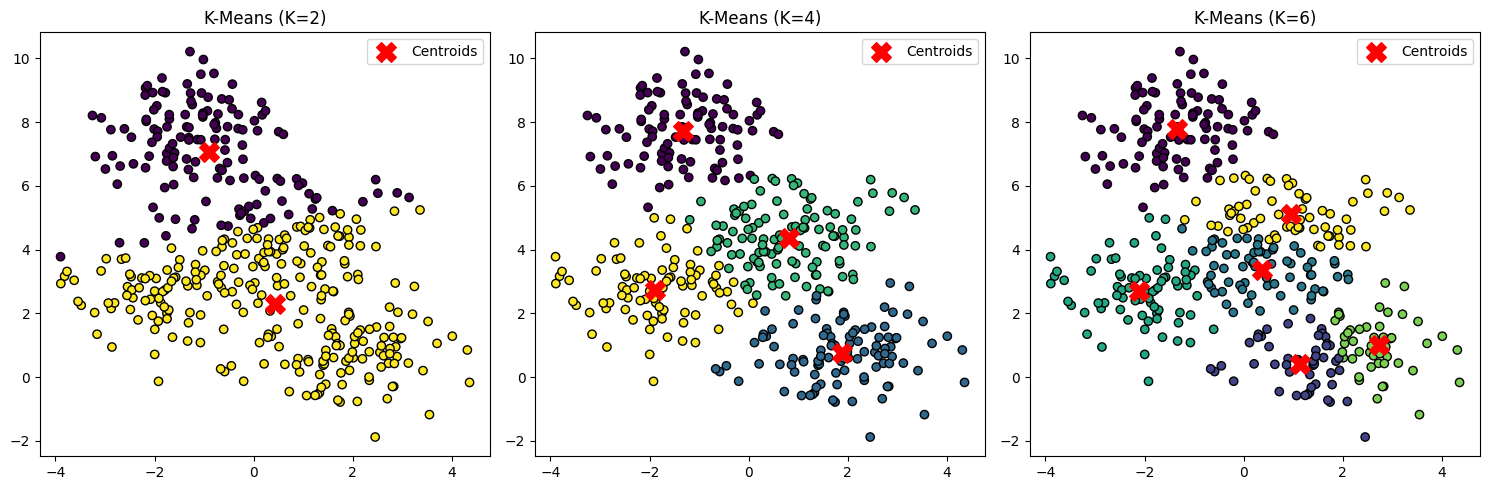

In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=400, centers=4, n_features=2, random_state=0)

# 시각화를 위한 subplot 설정
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k_values = [2, 4, 6]

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    s=200, c='red', marker='X', label='Centroids')
    axes[i].set_title(f'K-Means (K={k})')
    axes[i].legend()

plt.tight_layout()
plt.show()

문제 3 : Elbow Method - 최적 K찾기

K-Means는 사전에 K값을 지정해야 하기 때문에 적절한 군집 개수를 선택하는 과정이 중요하다. Elbow Method를 사용하여 최적의 군집 수를 탐색하시오. 데이터 생성 조건 샘플 수 : 500개 군집 수 : 5개 특징 수 : 2개 random_state : 10

수행 조건 K를 1부터 10까지 변화시키며 K-Means 수행

K값에 따른 SSE 그래프를 그리시오.

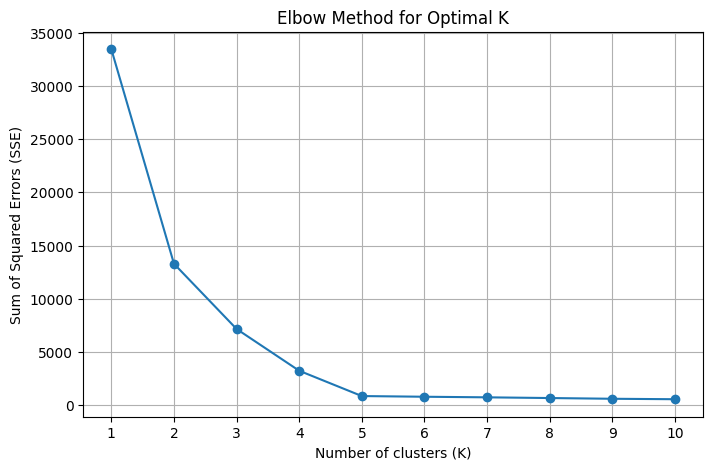

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=500,
    centers=5,
    n_features=2,
    random_state=10
)

#K-means 수행 과정을 작성해주세요
sse = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init='auto')
    kmeans.fit(X)
    sse.append(kmeans.inertia_) # SSE 값 저장

# K값에 따른 SSE 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

문제 4: make_blobs를 이용해 2차원 데이터를 생성하고,
K=3으로 K-Means 군집화를 수행하시오.

centroid를 함께 시각화할 것
random_state=42 사용

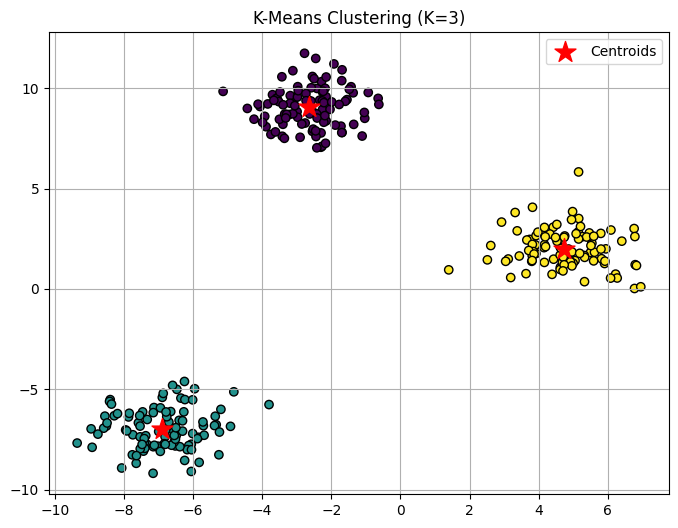

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성 및 KMeans 수행
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
# centroid 시각화
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='red', marker='*', label='Centroids')
plt.title('K-Means Clustering (K=3)')
plt.legend()
plt.grid(True)
plt.show()

문제 5:
iris 데이터셋에 대해
K=2
K=8로 각각 K-Means 군집화를 수행하고 결과를 시각화하시오.


이를 통해
K가 너무 작을 때의 문제점
K가 너무 클 때의 문제점을 서술하시오.

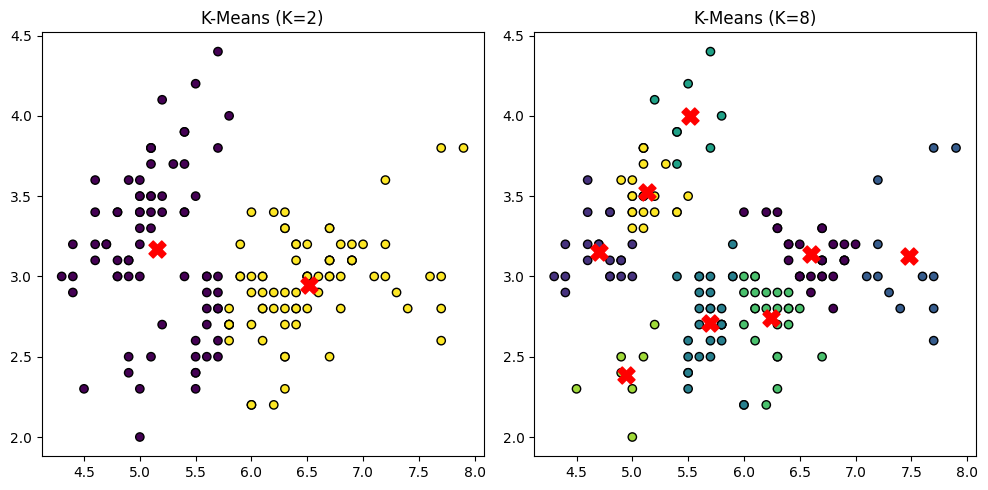

In [4]:
# iris data 불러오기
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]   # 앞 2개 feature만 사용

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10,5))

k_list = [2, 8]
for i, k in enumerate(k_list):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    s=150, c='red', marker='X')
    axes[i].set_title(f'K-Means (K={k})')

plt.tight_layout()
plt.show()

K가 너무 작을 때의 문제점: 데이터에 존재하는 실제 유의미한 패턴(군집)들을 구별해내지 못하고 뭉뚱그려 하나로 묶어버리는 과소적합(Underfitting) 문제가 발생.

K가 너무 클 때의 문제점: 동일한 특징을 가진 데이터들을 불필요하게 너무 잘게 쪼개어 노이즈(Noise)에 민감해지며, 군집화의 실질적인 의미(패턴 요약)를 상실하는 과대적합(Overfitting) 문제가 발생.

문제 6:

실루엣 계수(Silhouette Score)가 무엇인지 간단히 설명하시오.

실루엣 계수가 1, 0, 음수에 가까울 때 각각 어떤 의미를 가지는지 설명하시오.

실루엣 계수(Silhouette Score)는 각 데이터 포인트가 자신이 속한 군집과 얼마나 잘 맞는지(응집도), 그리고 인접한 다른 군집과는 얼마나 잘 분리되어 있는지(분리도)를 동시에 평가하는 지표이다. 수치는 -1에서 1 사이의 값을 가진다.

1에 가까울 때: 자신이 속한 군집과 매우 잘 뭉쳐 있고, 다른 군집과는 아주 멀리 떨어져 있는 완벽한 군집화 상태를 의미한다.

0에 가까울 때: 군집 간의 경계선에 위치하여 어느 군집에 속해도 이상하지 않은 모호한 상태를 의미한다.

음수일 때: 데이터 포인트가 잘못된 군집에 할당되었음을 의미한다.

문제 7:
iris 데이터셋에 대해 다음 조건으로 K-Means 군집화를 수행하시오.

**요구사항**

군집화를 수행하고 결과를 시각화하시오.

cluster_centers_를 출력하시오.

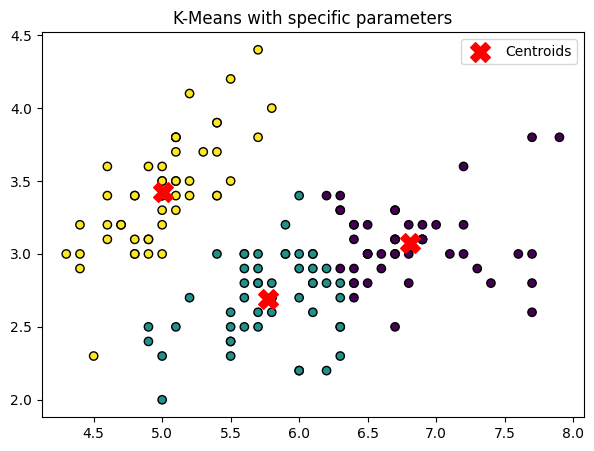

Cluster Centers:
 [[6.81276596 3.07446809]
 [5.77358491 2.69245283]
 [5.006      3.428     ]]


In [5]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data[:, :2]

# 요구사항에 맞춘 KMeans 수행
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
labels = kmeans.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means with specific parameters')
plt.legend()
plt.show()

# cluster_centers_ 출력
print("Cluster Centers:\n", kmeans.cluster_centers_)

문제 8: 다음 파라미터들의 역할을 간단히 설명하시오.

n_clusters

init

n_init

max_iter

random_state

n_clusters: 알고리즘이 찾고자 하는 최종 군집의 개수(K)를 지정.

init: 초기 군집 중심점(Centroid)을 설정하는 방식을 지정. ('k-means++'는 초기 중심점을 더 영리하게 분산시켜 수렴 속도와 성능을 높이는 방식.)

n_init: 초기 중심점 위치를 다르게 하여 K-Means 알고리즘을 몇 번 반복 실행할지 지정. 이 중 가장 결과(SSE)가 좋은 모델을 최종 선택.

max_iter: 알고리즘의 단일 실행 내에서 중심점을 이동시키는 최대 반복 횟수를 지정. 이 횟수 이전에 수렴하면 조기 종료.

random_state: 난수 발생 시드를 고정하여, 코드를 다시 실행해도 동일한 결과가 나오도록 재현성을 보장.

### Section B: 평균 이동, GMM, DBSCAN

#### 문제 1: 평균 이동(Mean Shift) 군집화의 이해

Mean Shift 알고리즘은 KMeans와 유사하게 거리 기반 군집화 방법 중 하나입니다. 이 알고리즘의 동작 방식에 대해 간략히 설명하고, `make_blobs`를 사용하여 가상의 데이터셋을 생성한 후 `MeanShift`를 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

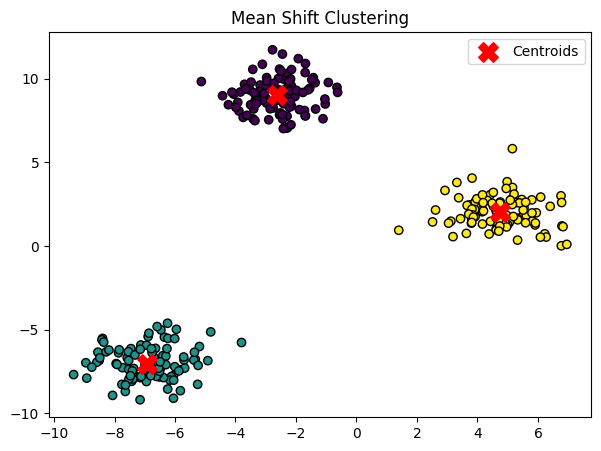

In [6]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# Mean Shift 수행
meanshift = MeanShift()
labels = meanshift.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.scatter(meanshift.cluster_centers_[:, 0], meanshift.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title('Mean Shift Clustering')
plt.legend()
plt.show()

#### 문제 2: Mean Shift 군집화 파라미터 이해 및 조정

Mean Shift 알고리즘에서 `bandwidth` 파라미터는 군집화 결과에 큰 영향을 미칩니다. `bandwidth` 값을 다르게 설정했을 때 군집화 결과가 어떻게 달라지는지 확인하기 위해, 다음 조건을 따라 코드를 작성하고 결과를 비교하여 설명하세요.

**데이터 생성 조건:** (문제 1과 동일)
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**MeanShift 설정:**
- Case 1: `bandwidth`를 `estimate_bandwidth`로 추정한 값 사용
- Case 2: `bandwidth`를 추정값의 0.5배로 설정
- Case 3: `bandwidth`를 추정값의 2배로 설정

각 Case별로 군집화 결과를 시각화하고, 군집의 개수 변화와 그 이유를 간략하게 설명하세요.

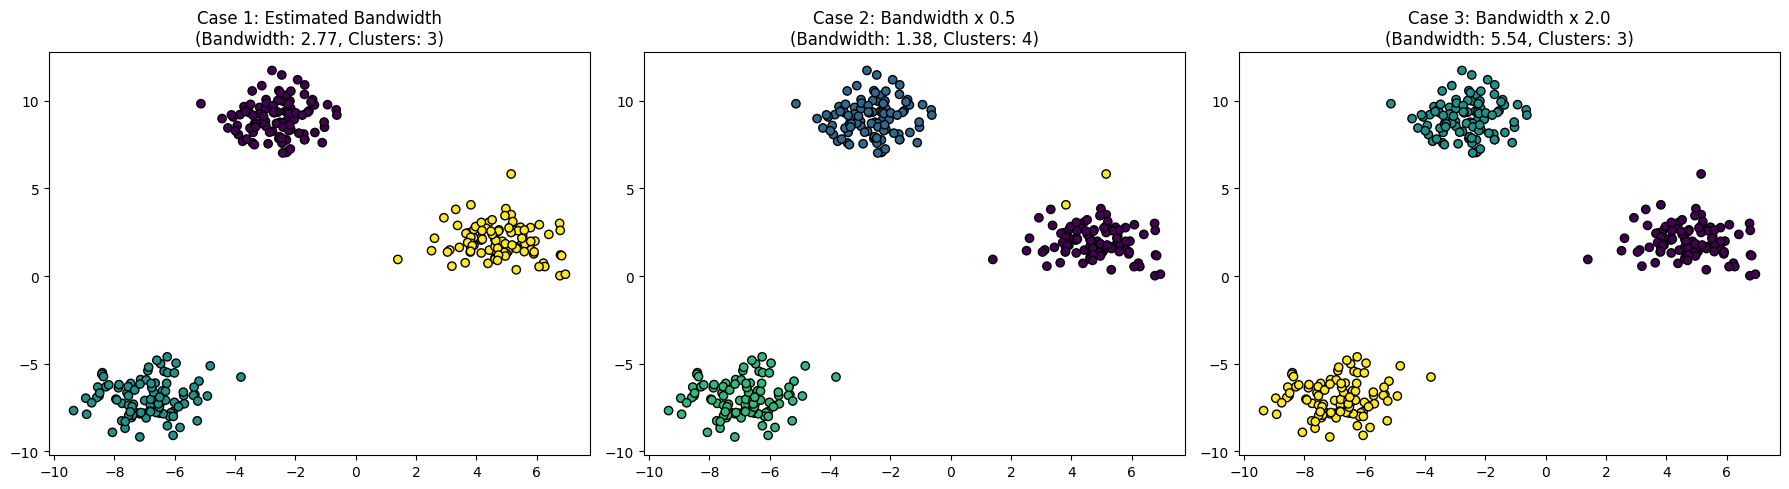

In [7]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# bandwidth 추정
best_bandwidth = estimate_bandwidth(X)

bandwidths = [best_bandwidth, best_bandwidth * 0.5, best_bandwidth * 2.0]
titles = ['Case 1: Estimated Bandwidth', 'Case 2: Bandwidth x 0.5', 'Case 3: Bandwidth x 2.0']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, bw in enumerate(bandwidths):
    ms = MeanShift(bandwidth=bw)
    labels = ms.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    axes[i].set_title(f"{titles[i]}\n(Bandwidth: {bw:.2f}, Clusters: {len(set(labels))})")

plt.tight_layout()
plt.show()

군집 개수 변화 이유: bandwidth는 데이터의 밀도를 추정할 때 사용하는 반경(창의 크기)을 의미함. 대역폭(bandwidth)이 작아지면(Case 2) 좁은 영역 내에서만 밀도를 계산하므로 군집이 매우 많게 과분할(Over-segmentation)되고, 반대로 대역폭이 커지면(Case 3) 넓은 영역을 한 번에 탐색하므로 군집이 하나 또는 소수로 합쳐지는 과소분할(Under-segmentation) 현상이 발생.

#### 문제 3: GMM (Gaussian Mixture Model) 군집화 및 KMeans와의 차이점

GMM은 각 군집이 가우시안 분포를 따른다고 가정하는 확률 기반 군집화 알고리즘입니다. GMM의 기본적인 개념과 KMeans와의 주요 차이점을 설명하고, `make_blobs`로 생성된 데이터에 `GaussianMixture`를 적용하여 군집화를 수행하고 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 400개
- 군집 수: 2개
- 특징 수: 2개
- 랜덤 시드: 0
- `cluster_std`를 각각 `[1.0, 2.5]`로 설정하여 타원형 분포를 갖도록 합니다.

**GMM 설정:**
- 군집 수: 2개
- 공분산 타입: `full`
- 랜덤 시드: 0

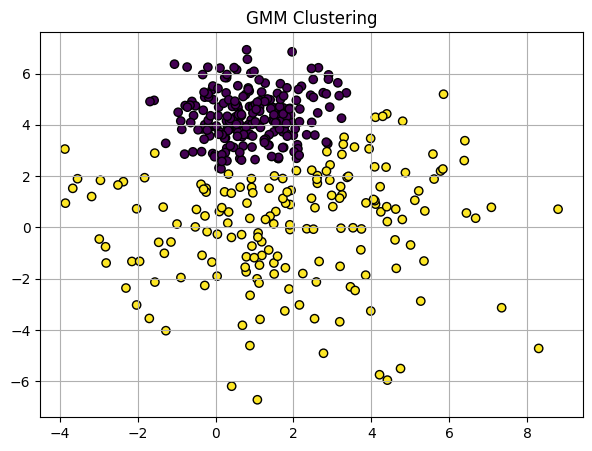

In [8]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# 타원형 분포를 위한 데이터 생성 (cluster_std 사용)
X, y = make_blobs(n_samples=400, centers=2, n_features=2,
                  cluster_std=[1.0, 2.5], random_state=0)

# GMM 적용
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
labels = gmm.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.title('GMM Clustering')
plt.grid(True)
plt.show()

#### 문제 4: DBSCAN (밀도 기반 군집화) 알고리즘 적용

DBSCAN은 밀도 기반 군집화 방법으로, 군집의 개수를 미리 지정할 필요가 없으며 다양한 형태의 군집을 찾을 수 있습니다. DBSCAN의 주요 파라미터(`eps`, `min_samples`)와 데이터 포인트의 세 가지 유형(`Core`, `Border`, `Noise`)에 대해 설명하고, `make_moons`를 사용하여 초승달 모양 데이터셋을 생성한 후 `DBSCAN`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 200개
- 노이즈 비율: 0.05
- 랜덤 시드: 42

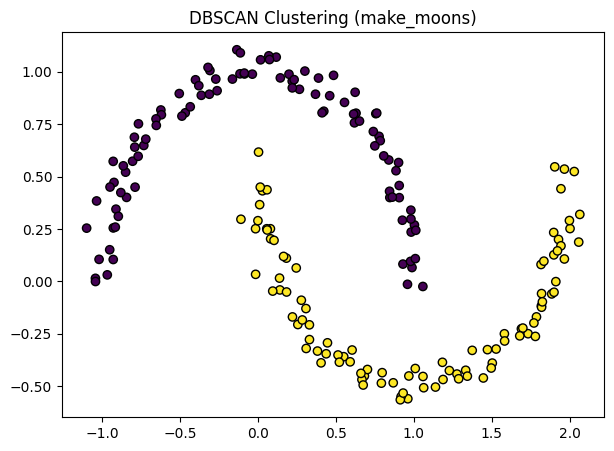

In [9]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

# DBSCAN 적용 (eps와 min_samples는 초승달 형태가 잘 잡히도록 적절히 지정)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.title('DBSCAN Clustering (make_moons)')
plt.show()

### Section C: 병합 군집, 계층적 군집, 고객 세그먼테이션 (RFM)

#### 문제 5: 계층적 군집화 (Agglomerative Clustering)의 이해

계층적 군집화는 데이터를 계층적으로 묶어 트리 형태(덴드로그램)의 구조를 만듭니다. 이 중 병합 군집(Agglomerative Clustering)의 개념에 대해 설명하고, `make_blobs`로 생성된 간단한 데이터셋에 `AgglomerativeClustering`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: `ward`

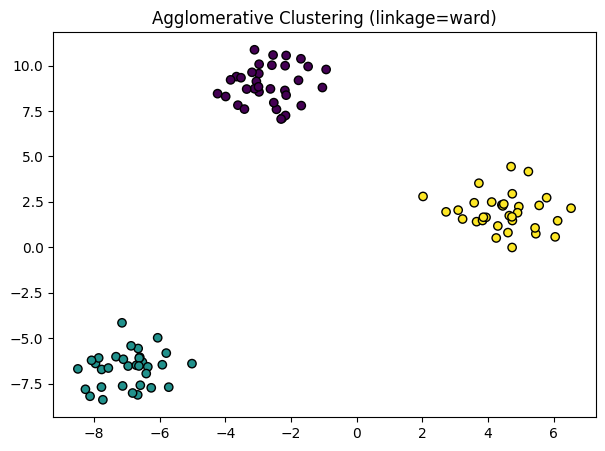

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

# Agglomerative Clustering 적용
agg_clust = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg_clust.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.title('Agglomerative Clustering (linkage=ward)')
plt.show()

#### 문제 6: 계층적 군집화의 Linkage 옵션

계층적 군집화에서 `linkage` 옵션은 군집 간의 유사성(거리)을 측정하는 방식을 정의하며, 군집화 결과에 중요한 영향을 미칩니다. `linkage` 옵션 중 `ward`, `complete`, `average` 세 가지 방식의 차이점을 간략히 설명하고, 다음 조건을 따라 `AgglomerativeClustering`을 적용하여 결과를 비교 시각화하세요.

**데이터 생성 조건:** (문제 5와 동일)
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: 각각 `ward`, `complete`, `average` 사용

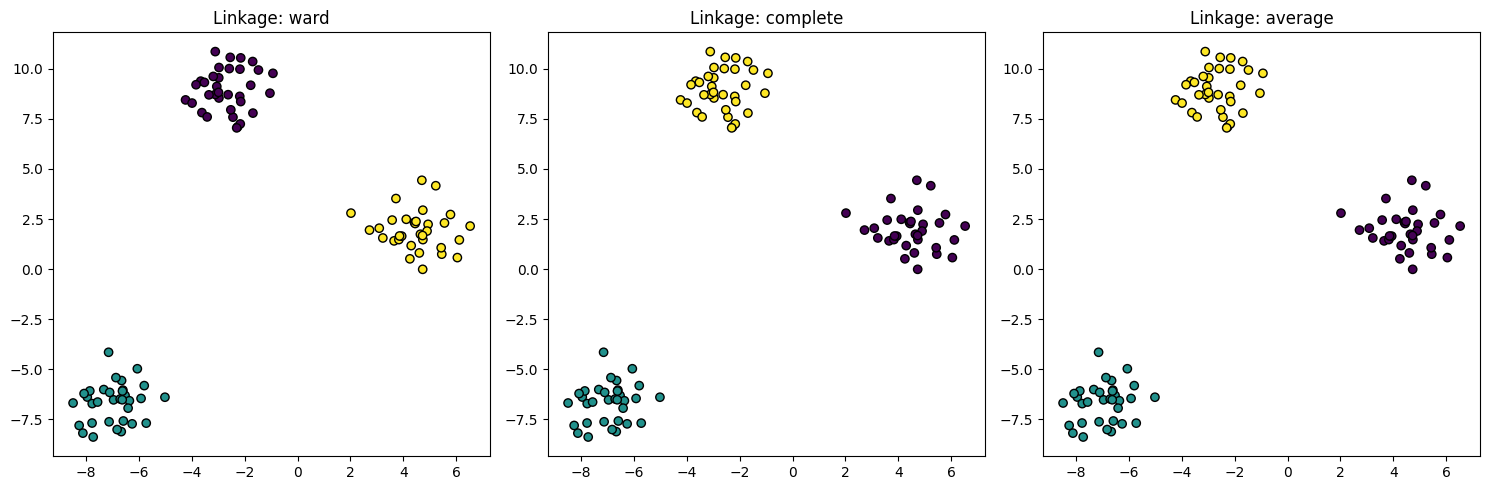

In [11]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

linkages = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, link in enumerate(linkages):
    agg = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agg.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    axes[i].set_title(f"Linkage: {link}")

plt.tight_layout()
plt.show()

#### 문제 7: 고객 세그먼테이션 (RFM 기법)의 개념

고객 세그먼테이션은 마케팅 분야에서 고객을 유사한 특성별로 그룹화하는 데 사용됩니다. 이 중 RFM (Recency, Frequency, Monetary) 기법은 가장 널리 사용되는 방법 중 하나입니다. RFM 각 지표의 의미를 설명하고, 왜 이 세 가지 지표가 고객 가치를 평가하고 세그먼테이션하는 데 효과적인지 간략하게 서술하세요.

Recency (최근성): 고객이 얼마나 최근에 상품/서비스를 구매했는지

Frequency (빈도): 고객이 특정 기간 동안 얼마나 자주 구매했는지

Monetary (금액): 고객이 특정 기간 동안 총 얼마를 지출했는지

효과적인 이유: 소비자의 과거 '행동 데이터'를 기반으로 하기 때문에 단순 인구통계학적 특성보다 예측력이 높음. 이 세 지표를 조합하면 충성 고객, 이탈 위험 고객, 신규 고객 등을 정확히 분류하여 맞춤형 마케팅 전략을 수립하는 데 매우 직관적이고 강력한 기준이 됨.

#### 문제 8: RFM 특징 데이터 전처리 및 생성

주어진 가상의 거래 데이터셋을 사용하여 RFM (Recency, Frequency, Monetary) 특징을 생성하세요. RFM은 고객 세그먼테이션을 위한 핵심 지표입니다. 각 RFM 지표를 계산하고, 최종적으로 고객별 RFM 데이터프레임을 생성하세요.

**데이터셋:** 다음 딕셔너리 형태의 데이터를 사용하여 `DataFrame`을 생성합니다.
```python
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
```

**계산 기준일:** `2023-03-01` (이 날짜를 기준으로 Recency를 계산합니다.)

**RFM 지표 계산:**
1. `PurchaseDate` 컬럼을 `datetime` 타입으로 변환합니다.
2. 각 고객(`CustomerID`)별로 다음 RFM 지표를 계산합니다.
   - **Recency:** `계산 기준일`로부터 가장 '최근' 구매일까지의 일수 (작을수록 좋음)
   - **Frequency:** 일정 기간 동안의 총 구매 '횟수'
   - **Monetary:** 일정 기간 동안의 총 구매 '금액' (Price의 합계)
3. 최종적으로 `CustomerID`, `Recency`, `Frequency`, `Monetary` 컬럼을 포함하는 RFM 데이터프레임을 생성하고 첫 5행을 출력합니다.

In [12]:
import pandas as pd
import datetime as dt

data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}

# 1. DataFrame 생성 및 날짜 타입 변환
df = pd.DataFrame(data)
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 계산 기준일 설정
current_date = pd.to_datetime('2023-03-01')

# 2 & 3. RFM 계산을 위해 CustomerID로 그룹화
rfm_df = df.groupby('CustomerID').agg(
    Recency=('PurchaseDate', lambda x: (current_date - x.max()).days), # 가장 최근 구매일로부터의 일수
    Frequency=('CustomerID', 'count'),                                 # 구매 횟수
    Monetary=('Price', 'sum')                                          # 총 구매 금액
).reset_index()

# 첫 5행 출력
print(rfm_df.head())

   CustomerID  Recency  Frequency  Monetary
0           1       28          3       450
1           2       19          2       170
2           3        9          4       630
3           4       24          2       320
4           5       52          2       600
